<a href="https://colab.research.google.com/github/anshulk-cmu/Mini-Eng-to-Es-NMT/blob/main/m25ai2036_assign_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# Phase 0: Setup & Imports
# ============================================================

# --- Install dependencies not pre-installed on Colab ---
!pip install -q datasets sacrebleu fasttext sentencepiece

import os
import re
import random
import math
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import fasttext
import sacrebleu
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


data/train-00000-of-00001.parquet:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/623k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/107067 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11897 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['eng', 'spa'],
        num_rows: 107067
    })
    test: Dataset({
        features: ['eng', 'spa'],
        num_rows: 11897
    })
})
Features: {'eng': Value('string'), 'spa': Value('string')}
Total pairs: 107067

First example: {'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}
Columns found: ['eng', 'spa']

Using first 50000 pairs
Train: 40000 | Val: 5000 | Test: 5000

--- Dataset Statistics ---


,Split,Count,Avg Words,Median Words,Max Words,Min Words
0,Train EN,40000,6.3,6.0,47,1
1,Train ES,40000,6.1,6.0,49,1
2,Val EN,5000,6.3,6.0,25,1
3,Val ES,5000,6.1,6.0,28,1
4,Test EN,5000,6.3,6.0,32,1
5,Test ES,5000,6.1,6.0,32,1



--- Random Sample Pairs ---


,English,Spanish
0,"Being poor, he can't buy it.","Pobre como es, no lo puede comprar."
1,She dumped him because she thought he was a jerk.,Ella le dejó porque pensaba que era un gilipol...
2,You did it again.,Lo has vuelto a hacer.
3,It is five years since they came to Japan.,Hace cinco años que vinieron a Japón.
4,You look like my sister.,Te pareces a mi hermana.


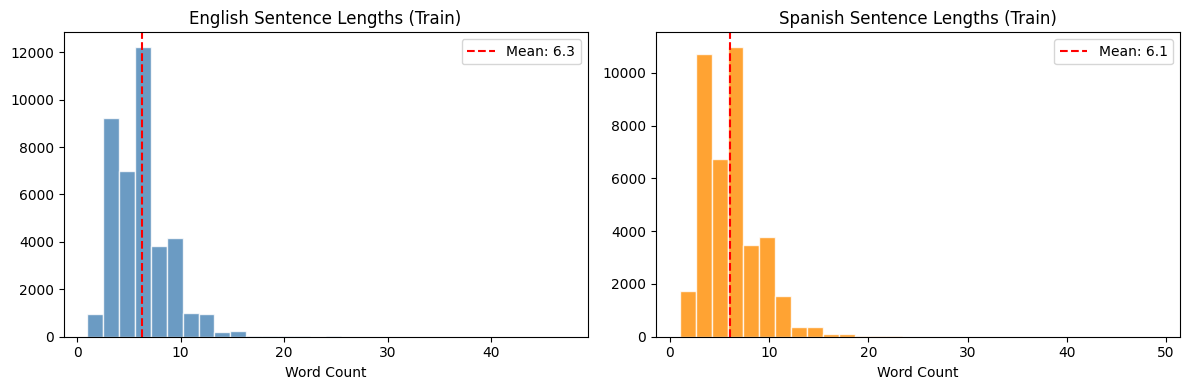


Sentences exceeding 18 words (our effective content limit):
  English: 86 (0.2%)
  Spanish: 97 (0.2%)


In [5]:
# ============================================================
# Phase 1: Data Loading & Exploration
# ============================================================

import pandas as pd
from datasets import load_dataset

# --- Load dataset ---
raw_dataset = load_dataset("OscarNav/spa-eng")
print(f"Dataset structure: {raw_dataset}")
print(f"Features: {raw_dataset['train'].features}")
print(f"Total pairs: {len(raw_dataset['train'])}")

# --- Extract English-Spanish pairs ---
data = raw_dataset['train']

# Inspect first example to determine column structure
print(f"\nFirst example: {data[0]}")

# Handle both common HF translation dataset formats
if 'translation' in data.features:
    en_texts = [ex['en'] for ex in data['translation']]
    es_texts = [ex['es'] for ex in data['translation']]
else:
    # Fallback: try direct column access
    cols = list(data.features.keys())
    print(f"Columns found: {cols}")
    en_texts = data[cols[0]]
    es_texts = data[cols[1]]

# --- Take first 50,000 pairs ---
N = 50_000
en_texts = en_texts[:N]
es_texts = es_texts[:N]
print(f"\nUsing first {N} pairs")

# --- Split: Train (40K) / Val (5K) / Test (5K) ---
train_en, train_es = en_texts[:40000], es_texts[:40000]
val_en,   val_es   = en_texts[40000:45000], es_texts[40000:45000]
test_en,  test_es  = en_texts[45000:50000], es_texts[45000:50000]

print(f"Train: {len(train_en)} | Val: {len(val_en)} | Test: {len(test_en)}")

# --- Exploratory Data Analysis ---
def compute_stats(texts, label):
    lengths = [len(t.split()) for t in texts]
    return {
        'Split': label,
        'Count': len(texts),
        'Avg Words': f"{np.mean(lengths):.1f}",
        'Median Words': f"{np.median(lengths):.1f}",
        'Max Words': max(lengths),
        'Min Words': min(lengths),
    }

stats = pd.DataFrame([
    compute_stats(train_en, 'Train EN'), compute_stats(train_es, 'Train ES'),
    compute_stats(val_en,   'Val EN'),   compute_stats(val_es,   'Val ES'),
    compute_stats(test_en,  'Test EN'),  compute_stats(test_es,  'Test ES'),
])
print("\n--- Dataset Statistics ---")
display(stats)

# --- Sample pairs ---
print("\n--- Random Sample Pairs ---")
sample_idx = random.sample(range(len(train_en)), 5)
sample_df = pd.DataFrame({
    'English': [train_en[i] for i in sample_idx],
    'Spanish': [train_es[i] for i in sample_idx],
})
display(sample_df)

# --- Sentence length distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
en_lens = [len(t.split()) for t in train_en]
es_lens = [len(t.split()) for t in train_es]

axes[0].hist(en_lens, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('English Sentence Lengths (Train)')
axes[0].set_xlabel('Word Count')
axes[0].axvline(np.mean(en_lens), color='red', linestyle='--', label=f'Mean: {np.mean(en_lens):.1f}')
axes[0].legend()

axes[1].hist(es_lens, bins=30, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Spanish Sentence Lengths (Train)')
axes[1].set_xlabel('Word Count')
axes[1].axvline(np.mean(es_lens), color='red', linestyle='--', label=f'Mean: {np.mean(es_lens):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSentences exceeding 18 words (our effective content limit):")
print(f"  English: {sum(1 for l in en_lens if l > 18)} ({sum(1 for l in en_lens if l > 18)/len(en_lens)*100:.1f}%)")
print(f"  Spanish: {sum(1 for l in es_lens if l > 18)} ({sum(1 for l in es_lens if l > 18)/len(es_lens)*100:.1f}%)")

In [6]:
# ============================================================
# Phase 2: Preprocessing Pipeline (Word-Level + BPE)
# ============================================================

import tempfile, os

# --- 2A: Shared Cleaning ---
def clean_text(text):
    """Lowercase, remove punctuation (keep Spanish accents), normalize whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-záéíóúñü0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean all splits
train_en_clean = [clean_text(t) for t in train_en]
train_es_clean = [clean_text(t) for t in train_es]
val_en_clean   = [clean_text(t) for t in val_en]
val_es_clean   = [clean_text(t) for t in val_es]
test_en_clean  = [clean_text(t) for t in test_en]
test_es_clean  = [clean_text(t) for t in test_es]

print(f"Cleaning examples:")
print(f"  Before: {train_en[0]}")
print(f"  After:  {train_en_clean[0]}")
print(f"  Before: {train_es[0]}")
print(f"  After:  {train_es_clean[0]}")

# --- 2B: Word-Level Tokenization ---
PAD_IDX, START_IDX, END_IDX, UNK_IDX = 0, 1, 2, 3
SPECIAL_TOKENS = {'<pad>': PAD_IDX, '<start>': START_IDX, '<end>': END_IDX, '<unk>': UNK_IDX}
MAX_LEN = 20
VOCAB_SIZE = 15000

def build_vocab(texts, max_size=VOCAB_SIZE):
    """Build vocab from training texts only. Returns word2idx, idx2word."""
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    most_common = counter.most_common(max_size - len(SPECIAL_TOKENS))
    word2idx = dict(SPECIAL_TOKENS)
    for word, _ in most_common:
        word2idx[word] = len(word2idx)
    idx2word = {v: k for k, v in word2idx.items()}
    return word2idx, idx2word

# Build vocabs from training set only
en_word2idx, en_idx2word = build_vocab(train_en_clean)
es_word2idx, es_idx2word = build_vocab(train_es_clean)

print(f"\nWord-Level Vocab — EN: {len(en_word2idx)} | ES: {len(es_word2idx)}")

def encode_word(tokens, word2idx, add_start=False, add_end=False, max_len=MAX_LEN):
    """Convert word list to index list with optional special tokens, truncated to max_len."""
    ids = []
    if add_start:
        ids.append(START_IDX)
    for w in tokens:
        ids.append(word2idx.get(w, UNK_IDX))
    if add_end:
        ids.append(END_IDX)
    return ids[:max_len]

def encode_word_dataset(en_texts, es_texts, en_w2i, es_w2i):
    """Encode full dataset: EN (no special tokens), ES_in (<start>...), ES_tgt (...<end>)."""
    en_ids, es_in_ids, es_tgt_ids = [], [], []
    for en, es in zip(en_texts, es_texts):
        en_tokens = en.split()
        es_tokens = es.split()
        en_ids.append(encode_word(en_tokens, en_w2i))
        es_in_ids.append(encode_word(es_tokens, es_w2i, add_start=True, max_len=MAX_LEN))
        es_tgt_ids.append(encode_word(es_tokens, es_w2i, add_end=True, max_len=MAX_LEN))
    return en_ids, es_in_ids, es_tgt_ids

# Encode all splits (word-level)
wl_train = encode_word_dataset(train_en_clean, train_es_clean, en_word2idx, es_word2idx)
wl_val   = encode_word_dataset(val_en_clean, val_es_clean, en_word2idx, es_word2idx)
wl_test  = encode_word_dataset(test_en_clean, test_es_clean, en_word2idx, es_word2idx)

# --- 2C: BPE Tokenization (SentencePiece) ---
BPE_VOCAB_SIZE = 8000

# Write combined training text to a temp file for SentencePiece training
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
    bpe_train_file = f.name
    for t in train_en_clean + train_es_clean:
        f.write(t + '\n')

# Train joint BPE model
spm.SentencePieceTrainer.train(
    input=bpe_train_file,
    model_prefix='bpe_joint',
    vocab_size=BPE_VOCAB_SIZE,
    model_type='bpe',
    pad_id=PAD_IDX,
    bos_id=START_IDX,
    eos_id=END_IDX,
    unk_id=UNK_IDX,
    character_coverage=1.0,
    max_sentence_length=4096,
)
os.remove(bpe_train_file)

# Load trained BPE model
sp = spm.SentencePieceProcessor()
sp.load('bpe_joint.model')
print(f"BPE Vocab: {sp.get_piece_size()}")

# Show BPE segmentation examples
for ex in ["hablando", "she is running quickly", "no tenemos donde quedarnos"]:
    print(f"  '{ex}' → {sp.encode_as_pieces(ex)}")

def encode_bpe_dataset(en_texts, es_texts, sp_model):
    """Encode using BPE. Same structure: EN, ES_in (<start>...), ES_tgt (...<end>)."""
    en_ids, es_in_ids, es_tgt_ids = [], [], []
    for en, es in zip(en_texts, es_texts):
        en_enc = sp_model.encode(en)[:MAX_LEN]
        es_enc = sp_model.encode(es)
        # ES input: <start> + tokens (truncate to MAX_LEN)
        es_in = [START_IDX] + es_enc
        es_in = es_in[:MAX_LEN]
        # ES target: tokens + <end> (truncate to MAX_LEN)
        es_tgt = es_enc + [END_IDX]
        es_tgt = es_tgt[:MAX_LEN]
        en_ids.append(en_enc)
        es_in_ids.append(es_in)
        es_tgt_ids.append(es_tgt)
    return en_ids, es_in_ids, es_tgt_ids

# Encode all splits (BPE)
bpe_train = encode_bpe_dataset(train_en_clean, train_es_clean, sp)
bpe_val   = encode_bpe_dataset(val_en_clean, val_es_clean, sp)
bpe_test  = encode_bpe_dataset(test_en_clean, test_es_clean, sp)

# --- BPE vs Word-Level comparison stats ---
wl_unk_count = sum(1 for seq in wl_test[2] for tok in seq if tok == UNK_IDX)
wl_tok_count = sum(len(seq) for seq in wl_test[2])
bpe_unk_count = sum(1 for seq in bpe_test[2] for tok in seq if tok == UNK_IDX)
bpe_tok_count = sum(len(seq) for seq in bpe_test[2])

wl_avg_len  = np.mean([len(seq) for seq in wl_train[0]])
bpe_avg_len = np.mean([len(seq) for seq in bpe_train[0]])

print(f"\n--- Tokenization Comparison (Test Set, Spanish Target) ---")
print(f"  Word-Level UNK rate: {wl_unk_count}/{wl_tok_count} ({wl_unk_count/wl_tok_count*100:.2f}%)")
print(f"  BPE UNK rate:        {bpe_unk_count}/{bpe_tok_count} ({bpe_unk_count/bpe_tok_count*100:.2f}%)")
print(f"  Avg EN tokens — Word-Level: {wl_avg_len:.1f} | BPE: {bpe_avg_len:.1f}")

# --- 2D: Dataset & DataLoader ---
BATCH_SIZE = 256

class TranslationDataset(Dataset):
    def __init__(self, en_ids, es_in_ids, es_tgt_ids):
        self.en = en_ids
        self.es_in = es_in_ids
        self.es_tgt = es_tgt_ids

    def __len__(self):
        return len(self.en)

    def __getitem__(self, idx):
        return (torch.tensor(self.en[idx], dtype=torch.long),
                torch.tensor(self.es_in[idx], dtype=torch.long),
                torch.tensor(self.es_tgt[idx], dtype=torch.long))

def collate_fn(batch):
    """Dynamic padding: pad to longest sequence in the batch, not globally."""
    en, es_in, es_tgt = zip(*batch)
    en    = nn.utils.rnn.pad_sequence(en,    batch_first=True, padding_value=PAD_IDX)
    es_in = nn.utils.rnn.pad_sequence(es_in, batch_first=True, padding_value=PAD_IDX)
    es_tgt = nn.utils.rnn.pad_sequence(es_tgt, batch_first=True, padding_value=PAD_IDX)
    return en, es_in, es_tgt

def make_loaders(encoded, batch_size=BATCH_SIZE, shuffle_train=True):
    """Create train/val/test DataLoaders from encoded (train, val, test) tuples."""
    train_ds = TranslationDataset(*encoded[0])
    val_ds   = TranslationDataset(*encoded[1])
    test_ds  = TranslationDataset(*encoded[2])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train,
                              collate_fn=collate_fn, pin_memory=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              collate_fn=collate_fn, pin_memory=True, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              collate_fn=collate_fn, pin_memory=True, num_workers=2)
    return train_loader, val_loader, test_loader

# Create DataLoaders for both tokenization schemes
wl_loaders  = make_loaders((wl_train, wl_val, wl_test))
bpe_loaders = make_loaders((bpe_train, bpe_val, bpe_test))

# Sanity check
en_batch, es_in_batch, es_tgt_batch = next(iter(wl_loaders[0]))
print(f"\n--- DataLoader Sanity Check (Word-Level, Train) ---")
print(f"  EN batch:     {en_batch.shape}")
print(f"  ES_in batch:  {es_in_batch.shape}")
print(f"  ES_tgt batch: {es_tgt_batch.shape}")
print(f"  Batches per epoch: {len(wl_loaders[0])}")

en_batch_b, _, _ = next(iter(bpe_loaders[0]))
print(f"\n--- DataLoader Sanity Check (BPE, Train) ---")
print(f"  EN batch:     {en_batch_b.shape}")
print(f"  Batches per epoch: {len(bpe_loaders[0])}")

Cleaning examples:
  Before: When the curtain went up, the stage was dark.
  After:  when the curtain went up the stage was dark
  Before: Al levantarse el telón, la escena estaba oscura.
  After:  al levantarse el telón la escena estaba oscura

Word-Level Vocab — EN: 9099 | ES: 15000
BPE Vocab: 8000
  'hablando' → ['▁hablando']
  'she is running quickly' → ['▁she', '▁is', '▁running', '▁quickly']
  'no tenemos donde quedarnos' → ['▁no', '▁tenemos', '▁donde', '▁qued', 'arnos']

--- Tokenization Comparison (Test Set, Spanish Target) ---
  Word-Level UNK rate: 1068/35486 (3.01%)
  BPE UNK rate:        0/40693 (0.00%)
  Avg EN tokens — Word-Level: 6.3 | BPE: 6.8

--- DataLoader Sanity Check (Word-Level, Train) ---
  EN batch:     torch.Size([256, 15])
  ES_in batch:  torch.Size([256, 19])
  ES_tgt batch: torch.Size([256, 19])
  Batches per epoch: 157

--- DataLoader Sanity Check (BPE, Train) ---
  EN batch:     torch.Size([256, 20])
  Batches per epoch: 157


In [7]:
# ============================================================
# Phase 3: Pre-trained Embeddings (FastText)
# ============================================================

import io, gzip, urllib.request

FASTTEXT_DIM = 300
D_MODEL = 256

def download_and_extract_vectors(url, vocab, label=""):
    """Stream .vec.gz file, extract vectors only for words in our vocab."""
    print(f"  Downloading {label}...", end=" ", flush=True)
    response = urllib.request.urlopen(url)
    data = gzip.decompress(response.read())
    lines = data.decode('utf-8', errors='ignore').splitlines()
    print(f"done. Total vectors in file: {lines[0].strip()}")

    vectors = {}
    for line in lines[1:]:
        parts = line.rstrip().split(' ')
        word = parts[0]
        if word in vocab:
            vectors[word] = np.array(parts[1:], dtype=np.float32)
    return vectors

def build_embedding_matrix(word2idx, vectors, dim=FASTTEXT_DIM):
    """Build embedding matrix. Use FastText vector if available, else random N(0, 0.01)."""
    matrix = np.random.normal(0, 0.01, (len(word2idx), dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0  # Keep padding as zeros
    found = 0
    for word, idx in word2idx.items():
        if word in vectors:
            matrix[idx] = vectors[word]
            found += 1
    print(f"  Matched: {found}/{len(word2idx)} ({found/len(word2idx)*100:.1f}%)")
    return matrix

# Download and extract only the vectors we need
EN_VEC_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz"
ES_VEC_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"

print("Loading FastText vectors (streaming, vocab-filtered):")
en_vectors = download_and_extract_vectors(EN_VEC_URL, set(en_word2idx.keys()), "English")
es_vectors = download_and_extract_vectors(ES_VEC_URL, set(es_word2idx.keys()), "Spanish")

# Build embedding matrices
print("\nBuilding embedding matrices:")
print("English:")
en_embed_matrix = build_embedding_matrix(en_word2idx, en_vectors)
print("Spanish:")
es_embed_matrix = build_embedding_matrix(es_word2idx, es_vectors)

print(f"\nEmbedding matrix shapes — EN: {en_embed_matrix.shape} | ES: {es_embed_matrix.shape}")
print(f"Projection needed: {FASTTEXT_DIM} → {D_MODEL} (learned linear layer in model)")

# Clean up to free memory
del en_vectors, es_vectors

Loading FastText vectors (streaming, vocab-filtered):

Building embedding matrices:
English:
  Matched: 8979/9099 (98.7%)
Spanish:
  Matched: 14824/15000 (98.8%)

Embedding matrix shapes — EN: (9099, 300) | ES: (15000, 300)
Projection needed: 300 → 256 (learned linear layer in model)


In [8]:
# ============================================================
# Phase 4: Model Architecture (Transformer from Scratch)
# ============================================================

# --- 4A: Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# --- 4B: Multi-Head Attention (from scratch) ---
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)

        Q = self.W_Q(query).view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_K(key).view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_V(value).view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention: softmax(QK^T / sqrt(d_k)) * V
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.W_O(context)

# --- 4C: Feed-Forward Network ---
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)

# --- 4D: Encoder (1 layer) ---
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        attn = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn))
        ff = self.ff(x)
        x = self.norm2(x + self.dropout(ff))
        return x

# --- 4E: Decoder (1 layer) ---
class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask=None, cross_mask=None):
        attn = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn))
        attn = self.cross_attn(x, enc_out, enc_out, cross_mask)
        x = self.norm2(x + self.dropout(attn))
        ff = self.ff(x)
        x = self.norm3(x + self.dropout(ff))
        return x

# --- 4F: Full Translator Model ---
class TranslatorModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=4,
                 d_ff=512, dropout=0.1, max_len=MAX_LEN,
                 pretrained_src_embeds=None, pretrained_tgt_embeds=None):
        super().__init__()
        self.d_model = d_model

        # Source embedding
        if pretrained_src_embeds is not None:
            ft_dim = pretrained_src_embeds.shape[1]
            self.src_embed = nn.Embedding.from_pretrained(
                torch.FloatTensor(pretrained_src_embeds), freeze=False, padding_idx=PAD_IDX)
            self.src_proj = nn.Linear(ft_dim, d_model)
        else:
            self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
            self.src_proj = None

        # Target embedding
        if pretrained_tgt_embeds is not None:
            ft_dim = pretrained_tgt_embeds.shape[1]
            self.tgt_embed = nn.Embedding.from_pretrained(
                torch.FloatTensor(pretrained_tgt_embeds), freeze=False, padding_idx=PAD_IDX)
            self.tgt_proj = nn.Linear(ft_dim, d_model)
        else:
            self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
            self.tgt_proj = None

        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
        self.encoder = Encoder(d_model, num_heads, d_ff, dropout)
        self.decoder = Decoder(d_model, num_heads, d_ff, dropout)
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)
        self.scale = math.sqrt(d_model)

    def _embed_src(self, src):
        x = self.src_embed(src)
        if self.src_proj is not None:
            x = self.src_proj(x)
        return self.pos_enc(x * self.scale)

    def _embed_tgt(self, tgt):
        x = self.tgt_embed(tgt)
        if self.tgt_proj is not None:
            x = self.tgt_proj(x)
        return self.pos_enc(x * self.scale)

    def _make_pad_mask(self, seq, pad_idx=PAD_IDX):
        """(B, 1, 1, seq_len) — broadcastable over heads and query positions."""
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

    def _make_causal_mask(self, size):
        """Lower-triangular mask (1, 1, size, size)."""
        mask = torch.tril(torch.ones(size, size, device=DEVICE)).unsqueeze(0).unsqueeze(0)
        return mask

    def _make_tgt_mask(self, tgt):
        """Combine causal mask with padding mask for decoder self-attention."""
        pad_mask = self._make_pad_mask(tgt)
        causal_mask = self._make_causal_mask(tgt.size(1))
        return pad_mask & (causal_mask.bool())

    def forward(self, src, tgt):
        src_mask = self._make_pad_mask(src)
        tgt_mask = self._make_tgt_mask(tgt)
        cross_mask = self._make_pad_mask(src)

        enc_out = self.encoder(self._embed_src(src), src_mask)
        dec_out = self.decoder(self._embed_tgt(tgt), enc_out, tgt_mask, cross_mask)
        return self.output_proj(dec_out)

    @torch.no_grad()
    def translate_greedy(self, src, max_len=MAX_LEN):
        """Greedy decoding: argmax at each step."""
        self.eval()
        src = src.to(DEVICE)
        src_mask = self._make_pad_mask(src)
        enc_out = self.encoder(self._embed_src(src), src_mask)
        cross_mask = self._make_pad_mask(src)

        B = src.size(0)
        decoder_input = torch.full((B, 1), START_IDX, dtype=torch.long, device=DEVICE)

        for _ in range(max_len - 1):
            tgt_mask = self._make_tgt_mask(decoder_input)
            dec_out = self.decoder(self._embed_tgt(decoder_input), enc_out, tgt_mask, cross_mask)
            logits = self.output_proj(dec_out[:, -1, :])
            next_token = logits.argmax(dim=-1, keepdim=True)
            decoder_input = torch.cat([decoder_input, next_token], dim=1)

            # Stop if all sequences have produced <end>
            if (next_token == END_IDX).all():
                break

        return decoder_input

    @torch.no_grad()
    def translate_beam(self, src, beam_width=3, alpha=0.6, max_len=MAX_LEN):
        """Beam search decoding with length normalization. Handles one sentence at a time."""
        self.eval()
        src = src.to(DEVICE)
        if src.dim() == 1:
            src = src.unsqueeze(0)

        src_mask = self._make_pad_mask(src)
        enc_out = self.encoder(self._embed_src(src), src_mask)
        cross_mask = self._make_pad_mask(src)

        # Each beam: (sequence_tensor, cumulative_log_prob)
        beams = [(torch.tensor([[START_IDX]], device=DEVICE), 0.0)]
        completed = []

        for _ in range(max_len - 1):
            all_candidates = []
            for seq, score in beams:
                # If this beam already ended, keep it
                if seq[0, -1].item() == END_IDX:
                    completed.append((seq, score))
                    continue

                tgt_mask = self._make_tgt_mask(seq)
                dec_out = self.decoder(self._embed_tgt(seq), enc_out, tgt_mask, cross_mask)
                logits = self.output_proj(dec_out[:, -1, :])
                log_probs = F.log_softmax(logits, dim=-1)

                topk_logp, topk_ids = log_probs.topk(beam_width, dim=-1)
                for i in range(beam_width):
                    new_seq = torch.cat([seq, topk_ids[:, i:i+1]], dim=1)
                    new_score = score + topk_logp[0, i].item()
                    all_candidates.append((new_seq, new_score))

            if not all_candidates:
                break

            # Length-normalized scoring
            all_candidates.sort(key=lambda x: x[1] / (x[0].size(1) ** alpha), reverse=True)
            beams = all_candidates[:beam_width]

        completed.extend(beams)
        # Return best by length-normalized score
        best = max(completed, key=lambda x: x[1] / (x[0].size(1) ** alpha))
        return best[0]

# --- Model Factory ---
def create_model(src_vocab_size, tgt_vocab_size, use_pretrained=False,
                 src_embed_matrix=None, tgt_embed_matrix=None):
    """Create model with or without pretrained embeddings."""
    model = TranslatorModel(
        src_vocab_size=src_vocab_size,
        tgt_vocab_size=tgt_vocab_size,
        d_model=D_MODEL,
        num_heads=4,
        d_ff=512,
        dropout=0.1,
        pretrained_src_embeds=src_embed_matrix if use_pretrained else None,
        pretrained_tgt_embeds=tgt_embed_matrix if use_pretrained else None,
    ).to(DEVICE)
    return model

# --- Sanity Check ---
test_model = create_model(len(en_word2idx), len(es_word2idx), use_pretrained=False)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Model parameters — Total: {total_params:,} | Trainable: {trainable_params:,}")

# Quick forward pass test
with torch.no_grad():
    test_src = en_batch.to(DEVICE)
    test_tgt = es_in_batch.to(DEVICE)
    test_out = test_model(test_src, test_tgt)
    print(f"Forward pass — Input: src={test_src.shape}, tgt={test_tgt.shape} → Output: {test_out.shape}")

# Quick greedy decode test
with torch.no_grad():
    test_pred = test_model.translate_greedy(test_src[:2])
    print(f"Greedy decode — Input: {test_src[:2].shape} → Output: {test_pred.shape}")

del test_model
torch.cuda.empty_cache()
print("Architecture verified.")

Model parameters — Total: 11,342,232 | Trainable: 11,342,232
Forward pass — Input: src=torch.Size([256, 15]), tgt=torch.Size([256, 19]) → Output: torch.Size([256, 19, 15000])
Greedy decode — Input: torch.Size([2, 15]) → Output: torch.Size([2, 20])
Architecture verified.
